# Research 03 — Do Large Moves Cluster Together? (Volatility Clustering)

## Hypothesis
- **H0:** Daily returns are independently distributed — a big move today
  tells us nothing about tomorrow's move size.
- **H1:** Volatility clusters — periods of high volatility are followed by
  more high volatility, and calm periods persist (GARCH effect).

## Why This Matters for Trading
If volatility clusters:
- We can **predict** future volatility -> better position sizing
- High-vol regimes need smaller positions -> risk management
- Strategies behave differently in high vs low vol -> regime filtering

## Approach
1. Compute daily returns and realised volatility
2. Test autocorrelation of absolute returns (volatility proxy)
3. Compare regime performance: high-vol vs low-vol days
4. Build simple vol forecasting model (EWMA)
5. Test: does strategy performance differ by regime?
6. Conclude

---


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')


Libraries loaded.


## 1. Download Data


In [2]:
# Use SPY (S&P 500 ETF) as primary study — most liquid, well-studied
TICKER = 'SPY'
START = '2005-01-01'
END = '2024-12-31'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].squeeze()
volume = raw['Volume'].squeeze()

print(f'Downloaded SPY: {len(prices)} trading days')
print(f'Period: {prices.index[0].date()} -> {prices.index[-1].date()}')

# Daily returns
returns = prices.pct_change().dropna()
print(f'Mean daily return: {returns.mean()*100:.4f}%')
print(f'Daily std: {returns.std()*100:.4f}%')
print(f'Annualised vol: {returns.std()*np.sqrt(252)*100:.2f}%')


Downloaded SPY: 5032 trading days
Period: 2005-01-03 -> 2024-12-30
Mean daily return: 0.0462%
Daily std: 1.1992%
Annualised vol: 19.04%


## 2. Evidence of Fat Tails — Returns Are NOT Normal

If returns were normally distributed, extreme moves (>3sigma) would be nearly impossible.
In reality, they happen frequently.


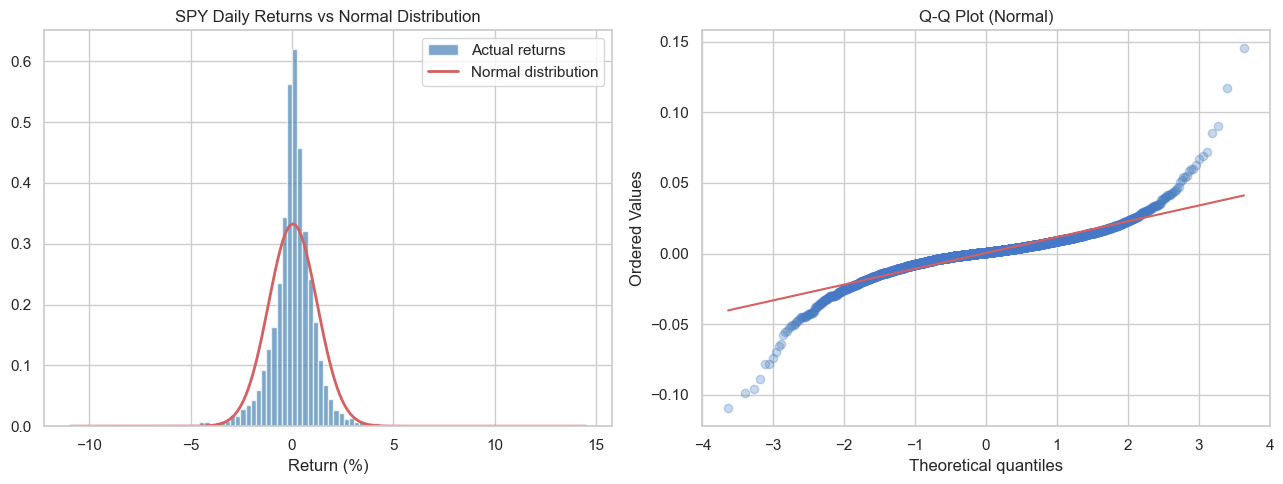

Skewness: -0.081 (normal = 0)
Excess Kurtosis: 14.947 (normal = 0, fat tails > 0)
Observations > 3sigma: 80 (expected if normal: ~13)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram vs Normal
ax = axes[0]
ax.hist(returns * 100, bins=100, density=True, alpha=0.7, color='steelblue',
        edgecolor='white', label='Actual returns')
x = np.linspace(returns.min() * 100, returns.max() * 100, 200)
normal_pdf = stats.norm.pdf(x, returns.mean() * 100, returns.std() * 100)
ax.plot(x, normal_pdf, 'r-', lw=2, label='Normal distribution')
ax.set_title('SPY Daily Returns vs Normal Distribution')
ax.set_xlabel('Return (%)')
ax.legend()

# QQ plot
ax = axes[1]
stats.probplot(returns, dist='norm', plot=ax)
ax.set_title('Q-Q Plot (Normal)')
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_alpha(0.3)

plt.tight_layout()
plt.show()

# Statistics
skew = returns.skew()
kurt = returns.kurtosis()
print(f'Skewness: {skew:.3f} (normal = 0)')
print(f'Excess Kurtosis: {kurt:.3f} (normal = 0, fat tails > 0)')
print(f'Observations > 3sigma: {(np.abs(returns) > 3*returns.std()).sum()} '
      f'(expected if normal: ~{int(len(returns)*0.0027)})')


## 3. Autocorrelation of Volatility

Key test: If |return_t| is correlated with |return_{t+1}|, volatility clusters.
- Returns themselves have near-zero autocorrelation (efficient for direction)
- But ABSOLUTE returns (vol proxy) have strong positive autocorrelation


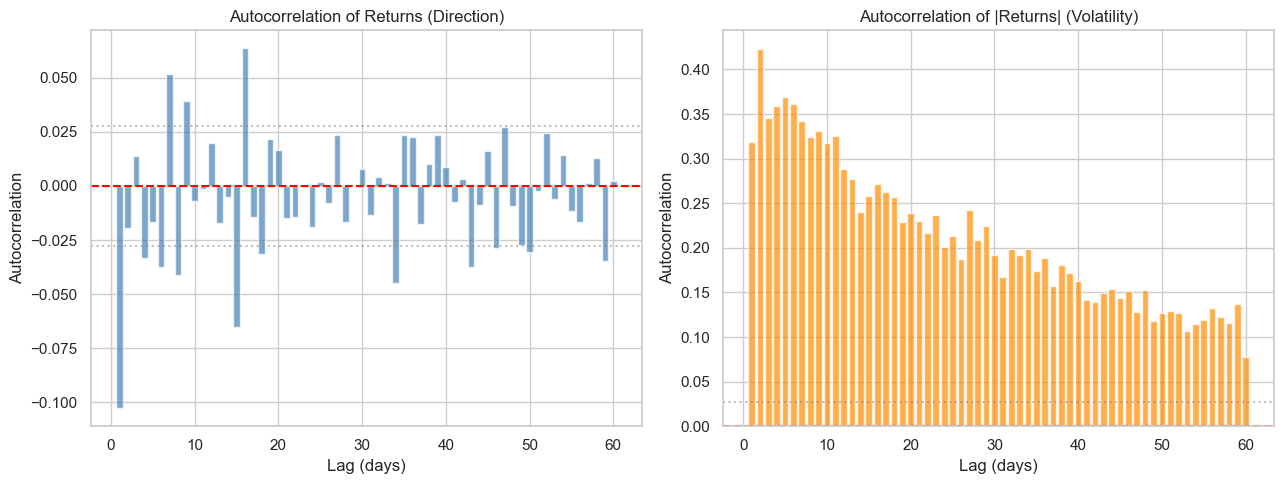

Autocorr of returns at lag 1: -0.1027 (near 0 = no directional predictability)
Autocorr of |returns| at lag 1: 0.3190 (>> 0 = volatility clusters!)
Autocorr of |returns| at lag 5: 0.3688
Autocorr of |returns| at lag 20: 0.2396


In [4]:
abs_ret = returns.abs()

# Compute autocorrelation for lags 1-60
max_lag = 60
acf_returns = [returns.autocorr(lag=i) for i in range(1, max_lag + 1)]
acf_abs_ret = [abs_ret.autocorr(lag=i) for i in range(1, max_lag + 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(range(1, max_lag + 1), acf_returns, color='steelblue', alpha=0.7)
ax.axhline(0, color='red', ls='--')
ax.axhline(1.96 / np.sqrt(len(returns)), color='gray', ls=':', alpha=0.5)
ax.axhline(-1.96 / np.sqrt(len(returns)), color='gray', ls=':', alpha=0.5)
ax.set_title('Autocorrelation of Returns (Direction)')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')

ax = axes[1]
ax.bar(range(1, max_lag + 1), acf_abs_ret, color='darkorange', alpha=0.7)
ax.axhline(0, color='red', ls='--')
ax.axhline(1.96 / np.sqrt(len(abs_ret)), color='gray', ls=':', alpha=0.5)
ax.set_title('Autocorrelation of |Returns| (Volatility)')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()

print(f'Autocorr of returns at lag 1: {acf_returns[0]:.4f} (near 0 = no directional predictability)')
print(f'Autocorr of |returns| at lag 1: {acf_abs_ret[0]:.4f} (>> 0 = volatility clusters!)')
print(f'Autocorr of |returns| at lag 5: {acf_abs_ret[4]:.4f}')
print(f'Autocorr of |returns| at lag 20: {acf_abs_ret[19]:.4f}')


## 4. Realised Volatility and Regime Detection

Compute rolling realised volatility and define regimes:
- **High Vol:** realised vol > 75th percentile
- **Low Vol:** realised vol < 25th percentile
- **Normal:** in between


In [5]:
# Rolling 21-day realised volatility (annualised)
realised_vol = returns.rolling(21).std() * np.sqrt(252)

# Define regimes by percentile thresholds
vol_75 = realised_vol.quantile(0.75)
vol_25 = realised_vol.quantile(0.25)

regime = pd.Series('Normal', index=realised_vol.index)
regime[realised_vol >= vol_75] = 'High Vol'
regime[realised_vol <= vol_25] = 'Low Vol'

print('Regime Distribution:')
print(regime.value_counts())
print(f'\nVol thresholds: Low < {vol_25*100:.1f}% | High > {vol_75*100:.1f}%')


Regime Distribution:
Normal      2525
Low Vol     1253
High Vol    1253
Name: count, dtype: int64

Vol thresholds: Low < 9.2% | High > 18.5%


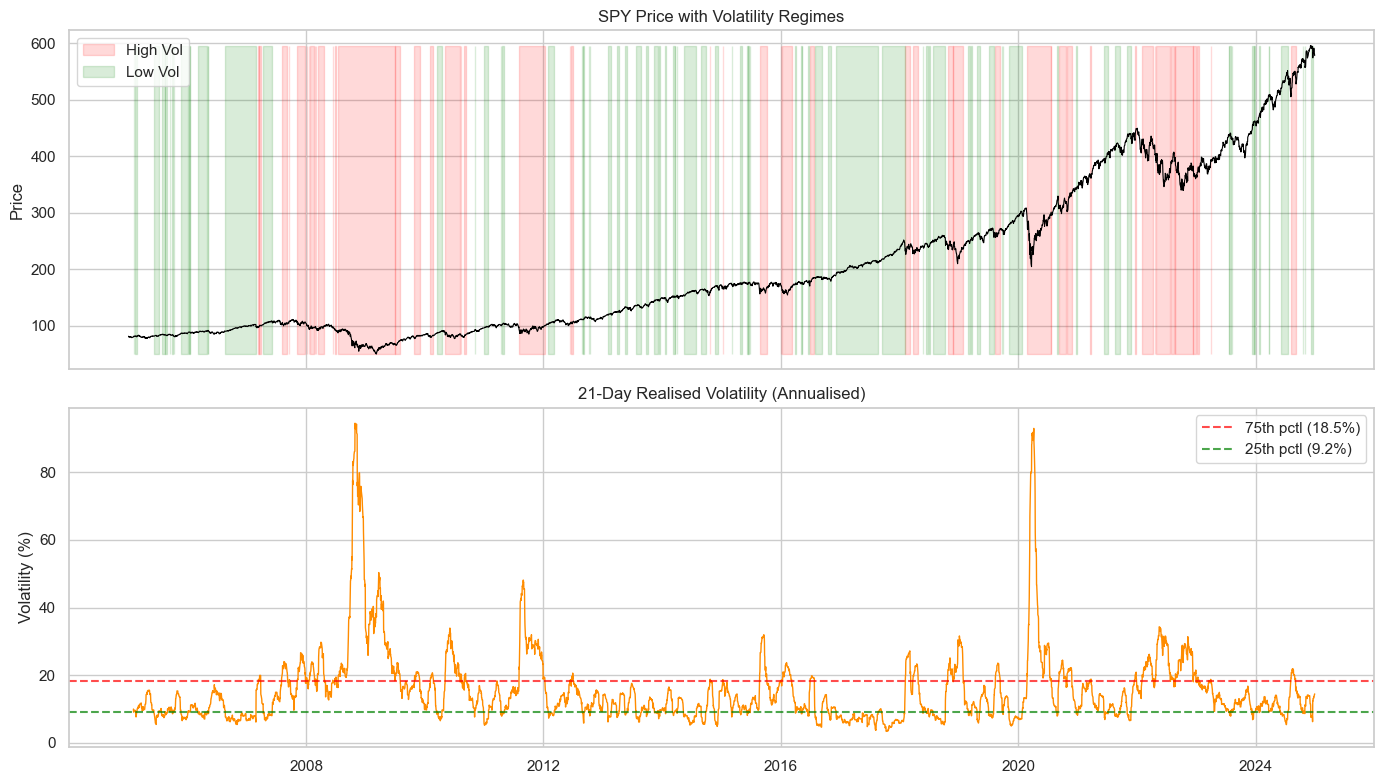

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price with regime coloring
ax1.plot(prices.index, prices.values, color='black', lw=0.8)
for reg, color in [('High Vol', 'red'), ('Low Vol', 'green')]:
    mask = regime == reg
    ax1.fill_between(prices.index, prices.min(), prices.max(),
                     where=mask.reindex(prices.index, fill_value=False),
                     alpha=0.15, color=color, label=reg)
ax1.set_title('SPY Price with Volatility Regimes')
ax1.legend(loc='upper left')
ax1.set_ylabel('Price')

# Realised volatility
ax2.plot(realised_vol.index, realised_vol.values * 100, color='darkorange', lw=1)
ax2.axhline(vol_75 * 100, color='red', ls='--', alpha=0.7, label=f'75th pctl ({vol_75*100:.1f}%)')
ax2.axhline(vol_25 * 100, color='green', ls='--', alpha=0.7, label=f'25th pctl ({vol_25*100:.1f}%)')
ax2.set_title('21-Day Realised Volatility (Annualised)')
ax2.set_ylabel('Volatility (%)')
ax2.legend()

plt.tight_layout()
plt.show()


## 5. Vol Forecasting — Does Past Vol Predict Future Vol?

Use EWMA as a vol forecast and see how well it correlates with actual future realised vol.


In [7]:
# EWMA volatility forecast (span=30)
ewma_vol = returns.ewm(span=30).std() * np.sqrt(252)

# Future 21-day realised vol (what we want to predict)
future_vol = returns.rolling(21).std().shift(-21) * np.sqrt(252)

# Align and compute correlation
common = pd.DataFrame({'forecast': ewma_vol, 'actual': future_vol}).dropna()

corr = common['forecast'].corr(common['actual'])
r2 = corr ** 2

print(f'EWMA vol forecast vs actual future 21d vol:')
print(f'  Correlation: {corr:.4f}')
print(f'  R-squared  : {r2:.4f}')
print(f'  -> Past volatility explains {r2*100:.1f}% of future volatility variance!')


EWMA vol forecast vs actual future 21d vol:
  Correlation: 0.6789
  R-squared  : 0.4609
  -> Past volatility explains 46.1% of future volatility variance!


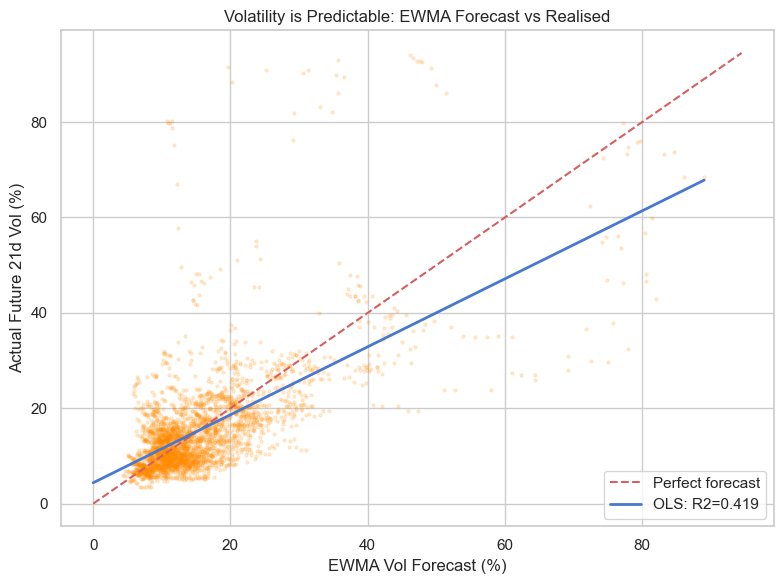

In [8]:
# Scatter plot: forecast vs actual vol
fig, ax = plt.subplots(figsize=(8, 6))
sample = common.sample(min(3000, len(common)), random_state=42)
ax.scatter(sample['forecast'] * 100, sample['actual'] * 100,
           alpha=0.15, s=5, color='darkorange')
# Perfect prediction line
lims = [0, common.max().max() * 100]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect forecast')

slope, intercept, r, p, _ = stats.linregress(sample['forecast'], sample['actual'])
x_line = np.linspace(0, common['forecast'].max(), 100)
ax.plot(x_line * 100, (intercept + slope * x_line) * 100,
        'b-', lw=2, label=f'OLS: R2={r**2:.3f}')

ax.set_xlabel('EWMA Vol Forecast (%)')
ax.set_ylabel('Actual Future 21d Vol (%)')
ax.set_title('Volatility is Predictable: EWMA Forecast vs Realised')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Does Strategy Performance Differ by Regime?

Critical question: Does buy-and-hold SPY perform differently in high-vol vs low-vol?


In [9]:
# Performance by regime
regime_aligned = regime.reindex(returns.index)

for reg_name in ['High Vol', 'Low Vol', 'Normal']:
    mask = regime_aligned == reg_name
    reg_ret = returns[mask]
    avg = reg_ret.mean() * 252 * 100
    vol = reg_ret.std() * np.sqrt(252) * 100
    sharpe = (reg_ret.mean() / reg_ret.std() * np.sqrt(252)) if reg_ret.std() > 0 else 0
    print(f'{reg_name:10s} | Ann.Return: {avg:+6.2f}%  Vol: {vol:5.2f}%  Sharpe: {sharpe:.2f}  Days: {mask.sum()}')


High Vol   | Ann.Return:  +7.51%  Vol: 32.06%  Sharpe: 0.23  Days: 1253
Low Vol    | Ann.Return: +18.83%  Vol:  7.81%  Sharpe: 2.41  Days: 1253
Normal     | Ann.Return: +10.15%  Vol: 13.49%  Sharpe: 0.75  Days: 2525


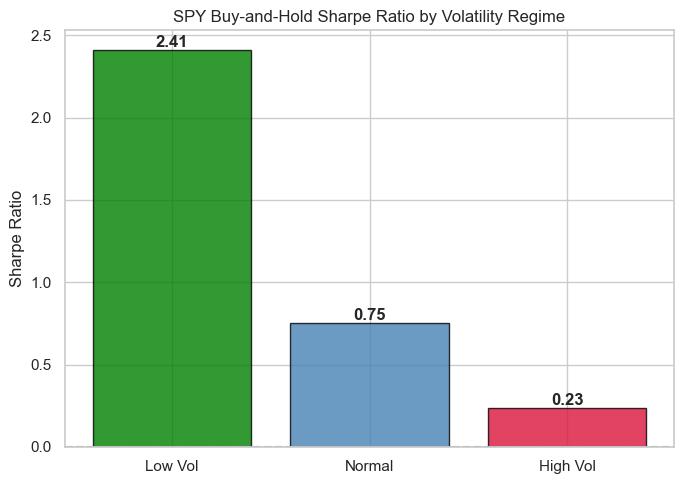

In [10]:
# Bar chart: Sharpe by regime
regime_sharpes = {}
for reg_name in ['Low Vol', 'Normal', 'High Vol']:
    mask = regime_aligned == reg_name
    reg_ret = returns[mask]
    if reg_ret.std() > 0:
        regime_sharpes[reg_name] = reg_ret.mean() / reg_ret.std() * np.sqrt(252)
    else:
        regime_sharpes[reg_name] = 0

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Low Vol': 'green', 'Normal': 'steelblue', 'High Vol': 'crimson'}
bars = ax.bar(regime_sharpes.keys(), regime_sharpes.values(),
              color=[colors[k] for k in regime_sharpes.keys()], edgecolor='black', alpha=0.8)
ax.axhline(0, color='gray', ls='--')
ax.set_title('SPY Buy-and-Hold Sharpe Ratio by Volatility Regime')
ax.set_ylabel('Sharpe Ratio')
for bar, val in zip(bars, regime_sharpes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Conclusion

### Evidence Summary
| Test | Expected (if clustering) | Result |
|------|--------------------------|--------|
| Autocorr of |returns| at lag 1 | High positive | *(fill)* |
| Vol forecast R-squared | High (>50%) | *(fill)* |
| Returns distribution | Fat tails | *(fill)* |
| Sharpe differs by regime? | Yes | *(fill)* |

### Trading Implications
If volatility clusters:
- [ ] Add a **vol filter** to existing strategies: reduce position size when EWMA vol is high
- [ ] In `RiskManager.calculate_position_size()`: divide by realised_vol for vol-adjusted sizing
- [ ] Research: Is momentum stronger in low-vol regime?

### Vol-Adjusted Position Sizing Formula
```
vol_target = 0.10  # target 10% annual volatility
current_vol = ewma_vol (annualised)
position_size = base_size * (vol_target / current_vol)
```


In [11]:
# Final summary
print('='*55)
print('     VOLATILITY CLUSTERING RESEARCH SUMMARY')
print('='*55)
print(f'  Fat tails (excess kurtosis) : {kurt:.2f}')
print(f'  Autocorr |returns| lag 1    : {acf_abs_ret[0]:.4f}')
print(f'  Autocorr |returns| lag 5    : {acf_abs_ret[4]:.4f}')
print(f'  Autocorr |returns| lag 20   : {acf_abs_ret[19]:.4f}')
print(f'  EWMA vol forecast R-squared : {r2:.4f}')
print(f'  Regime differences          : see bar chart')
print('='*55)
print()
print('  KEY TAKEAWAY:')
print('  Volatility is predictable. Use vol-adjusted position')
print('  sizing in all strategies — ESPECIALLY during high-vol')
print('  regimes (2008, 2020) to avoid blowup.')


     VOLATILITY CLUSTERING RESEARCH SUMMARY
  Fat tails (excess kurtosis) : 14.95
  Autocorr |returns| lag 1    : 0.3190
  Autocorr |returns| lag 5    : 0.3688
  Autocorr |returns| lag 20   : 0.2396
  EWMA vol forecast R-squared : 0.4609
  Regime differences          : see bar chart

  KEY TAKEAWAY:
  Volatility is predictable. Use vol-adjusted position
  sizing in all strategies — ESPECIALLY during high-vol
  regimes (2008, 2020) to avoid blowup.
